l---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [1]:
from typing import Any

# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torch import Tensor
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, Dataset
from torchvision.models import list_models, get_model
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:

# buona pratica fare un'analisi esplorativa del dataset

# prima cosa da fare se hai una GPU sulla macchina-->definiamo la variabile device
device = "cuda" if torch.cuda.is_available() else "cpu"


# facciamo lo split tra train e test
# all'inizio vediamo senza l'uso della trasformazione in tensori propio per vedere come effettivamente sono salvati

ds_train = GTSRB("_data/.", split="train", download=True) # train
ds_test = GTSRB("_data/.", split="test", download=True) # test

Debug per vedere se effettivamente uso la GPU

In [3]:
print(device)

cuda


Creiamo una funzione per la visualizzazione

In [4]:
def visualize(sample: list[tuple[Any, Any]]):
    plt.figure(figsize=(15,20))
    for (idx, (image, label)) in enumerate(sample):
        plt.subplot(10,10,idx+1)
        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"CLS: {label}")
        plt.axis('off')

Vediamo adesso come sono salvati i dati in generale e gli elementi

In [5]:
# visione generale del dataset caricato
print(ds_train)
print(ds_test)
# visione dell'elemento
print(ds_train[0]) # è un PIL.Image di dimensione 29x30

ds_train[0][0] # vedo l'immagine

# quasi tutti i dataset vengono forniti così immagine + etichetta però nella pratica noi lavoriamo con altri valori (tensori pytorch)

Dataset GTSRB
    Number of datapoints: 26640
    Root location: _data/.
Dataset GTSRB
    Number of datapoints: 12630
    Root location: _data/.
(<PIL.Image.Image image mode=RGB size=29x30 at 0x1EC2C66CAD0>, 0)


Convertiamo a una struttura dati a noi più affine

## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

In [6]:
# versione senza warning
transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

ds_train = GTSRB("_data/.", split="train", transform=transform, download=True)
ds_test = GTSRB("_data/.", split="test", transform=transform, download=True)

In [7]:
print(ds_train[0][0].shape) # [C, H, W] per una questione di efficienza e da tenere in considerazione per il futuro
ds_train[0][1]

torch.Size([3, 30, 29])


0

Utilissimo la visualizzazione di un sottocampione

In [8]:
# funzione per prendere un sottocampione
def getSample(num_sample: int = 100):
    image_sample = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_sample)]
    return image_sample

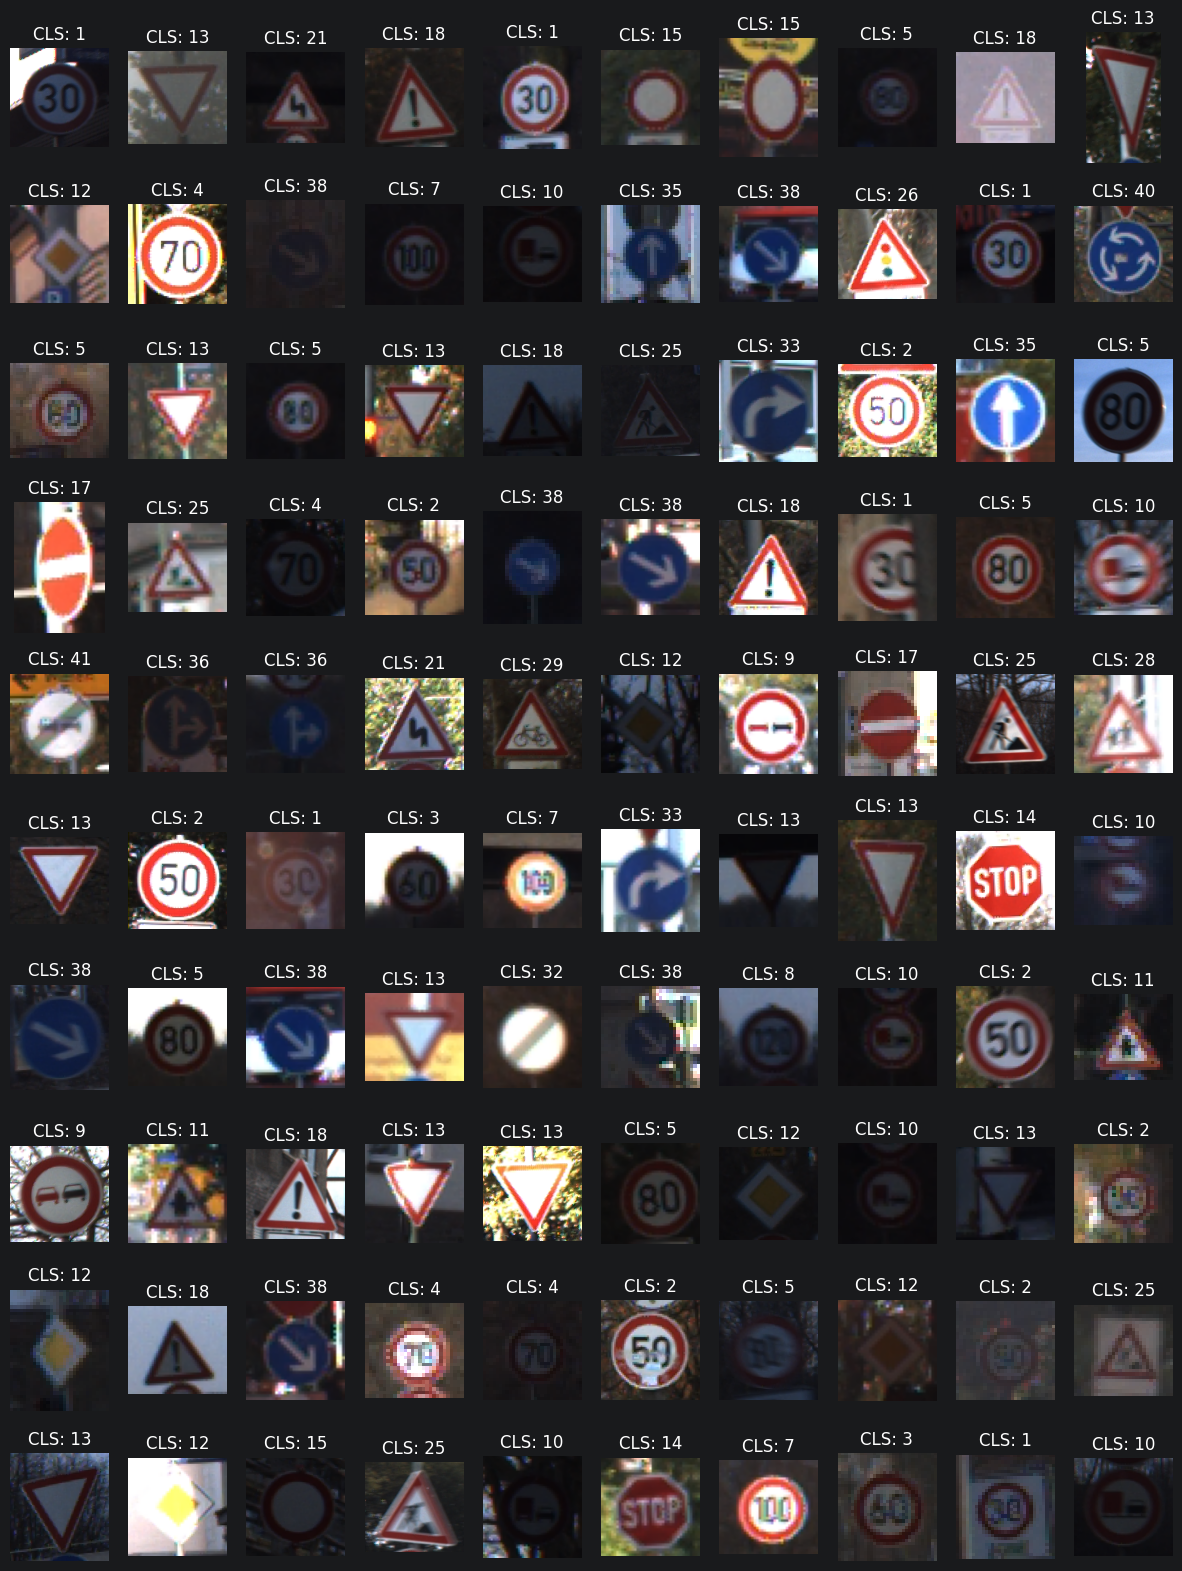

In [9]:
# selezionamo a caso 100 immagini dal training
image_sample = getSample() # lista

# visualizzazione grafica
visualize(image_sample)

# cosa si può notare? Risoluzione diversa (crop per vedere esclusivamente il cartello) no batch di immagini di dimensioni diverse

Proviamo a raccogliere delle statistiche: distribuzione altezze, larghezze, classi

Sbilanciato o no?

In [10]:
# utile convertire le statistiche in un dataframe (training)
df_stats = pd.DataFrame([(label, image.shape[1], image.shape[2]) for (image, label) in ds_train], columns=["CLS", "HEIGHT", "WIDTH"])
df_stats["AR"] = df_stats["HEIGHT"] / df_stats["WIDTH"] # colonna aspetto-ratio

In [11]:
# visualizziamo la descrizione del dataframe
df_stats.describe()

,CLS,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,0.997107
std,12.044099,23.161523,24.373418,0.084101
min,0.000000,25.000000,25.000000,0.705314
25%,5.000000,35.000000,35.000000,0.957447
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.028571
max,42.000000,225.000000,243.000000,2.716418


## Osservazioni
cosa osserviamo dalla tabella?

- Altezza e Larghezza hanno una varianza altina
- Altezza e Larghezza hanno la stessa media
- discrepanza tra Altezza e Larghezza minima e massima
- osservando i quantili abbiamo delle immagini outlier molto grosse

Stampiamo dei grafici

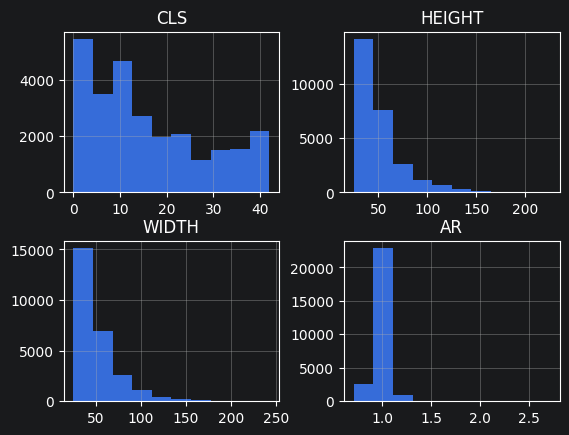

In [12]:
_ = df_stats.hist()

così vediamo la vera distribuzione: notiamo che la concentrazione delle immagini si trova prevelentemente prima di 50 per altezza e lunghezza, classi non perfettamente bilanciate e non troppo sbilanciate (tanti valori per le classi) quindi non è il caso di trattarlo come un caso sbilanciato.

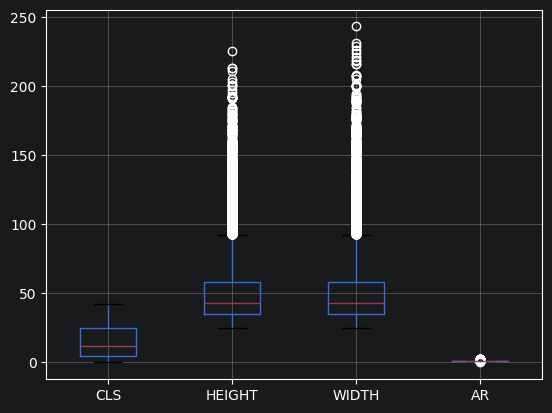

In [13]:
_ = df_stats.boxplot()

I BoxPlot forniscono l'idea di avere eccessivi outlier

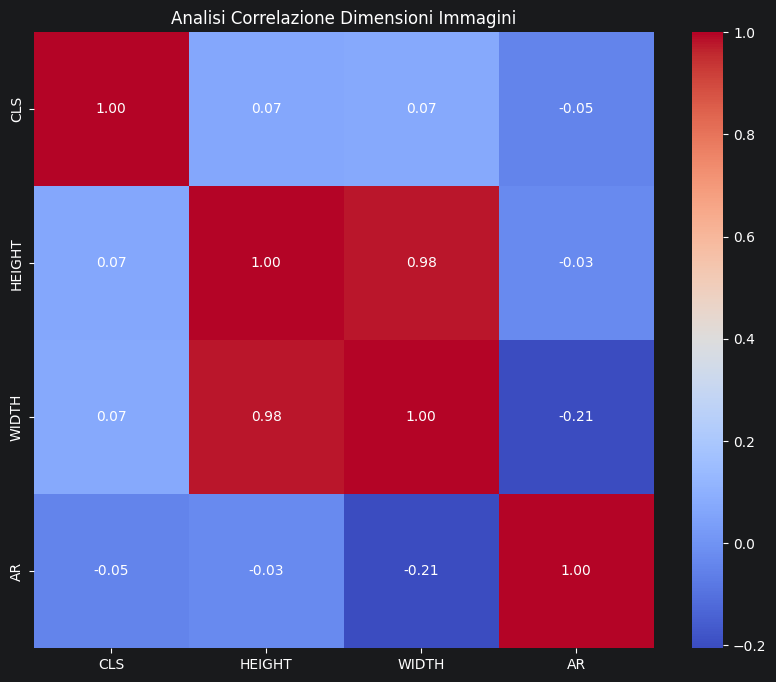

In [14]:
plt.figure(figsize=(10, 8))
# Calcoliamo la correlazione e creiamo il grafico
sns.heatmap(df_stats.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Analisi Correlazione Dimensioni Immagini")
plt.show()

l'ho fatto solo per curiosità sul fare le heatmap di correlazione non ci fornisce informazioni aggiuntive

Come gestiamo la differenza di dimensioni nel dataset?

In [15]:
# possibile soluzione
# crop (70) in modo che la dimensione più piccola sia 70, poi un random crop (64, 64) così ci assicura le stesse dimensioni e un'invarianza rispetto alla traslazione e normalizzarlo con i valori di imageNet (resNet) se non uso resNet devo modificare quei valori
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
ds_train = GTSRB("_data/.", split="train", transform=transform, download=True)
ds_test = GTSRB("_data/.", split="test", transform=transform, download=True) # non mi torna che facciamo le trasformazioni anche al test

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..1.0713727].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..1.1759479].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..-0.39267966].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..0.6182137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..-1.0027015].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2

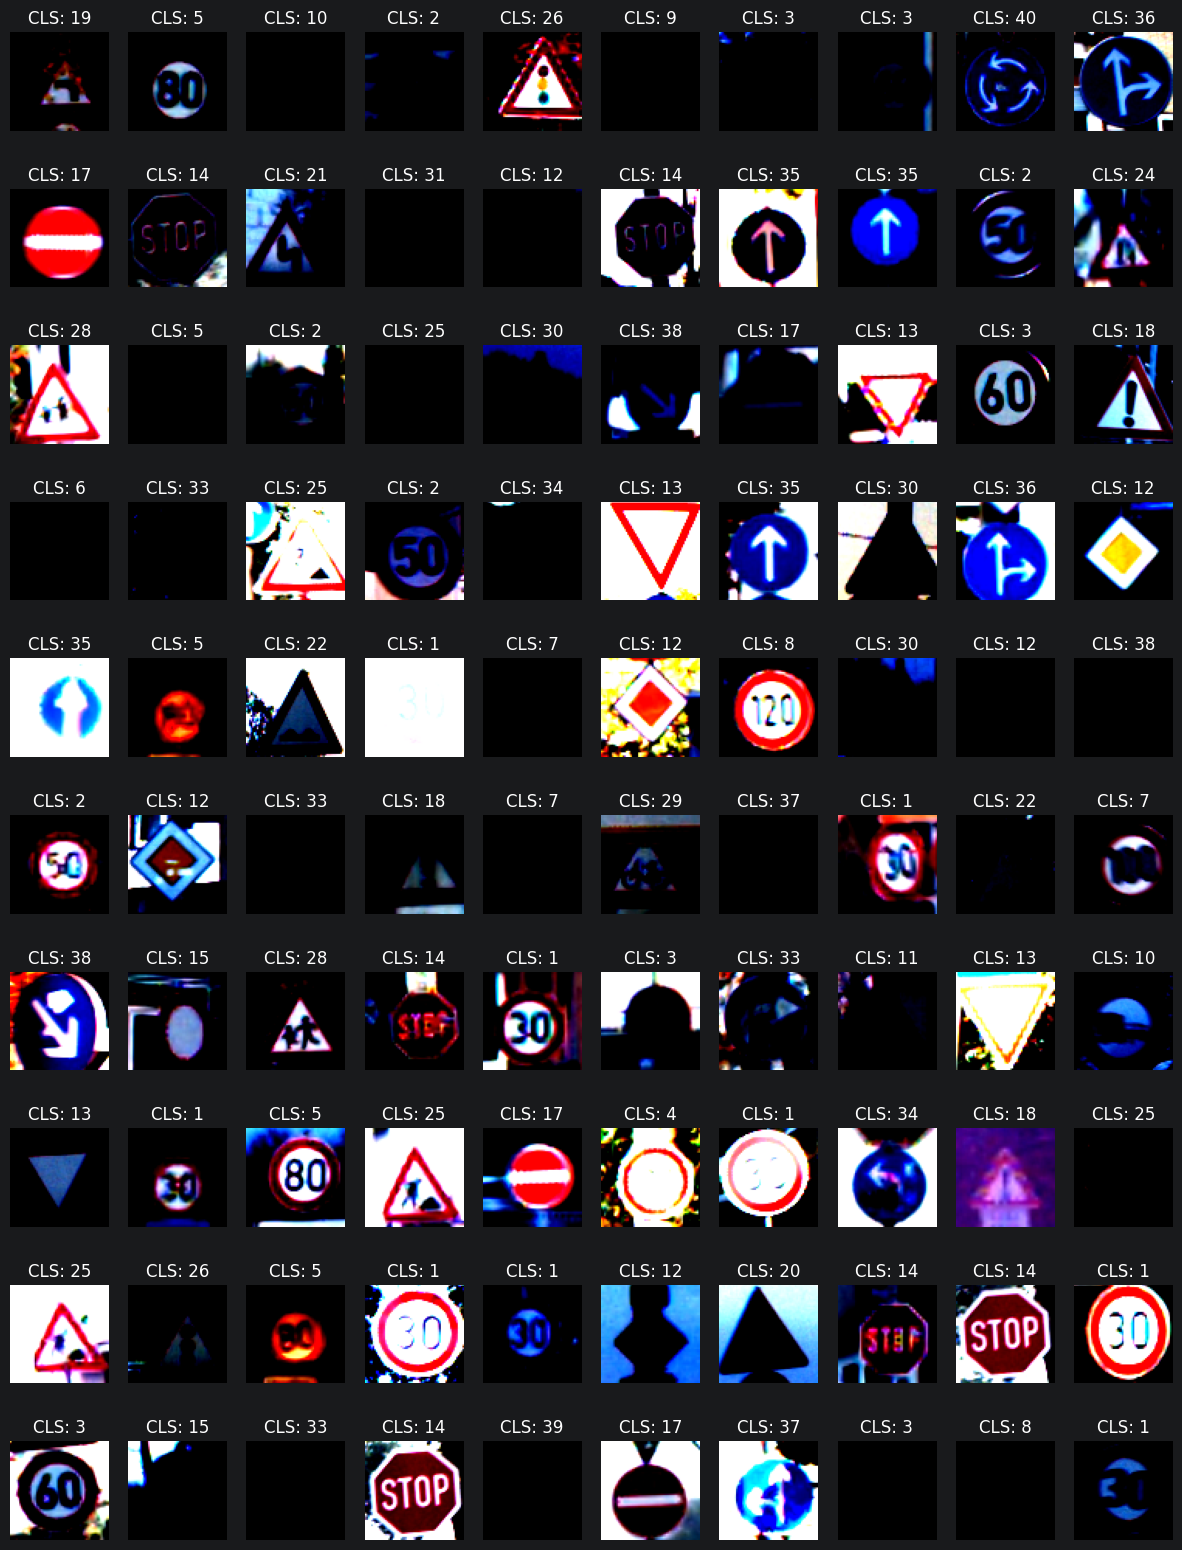

In [16]:
# visualizzazione con le trasformazioni
image_sample = getSample()
visualize(image_sample)

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [17]:

# variabili globali
batch_size= 1024


Per ottenere tutti i pre trained models di torchvision

In [18]:
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [19]:
# train dataloader
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)



#caricamento modello (default preso da torchivision specifiche)
model = get_model("resnet18", weights="DEFAULT").to(device)

Visualizzazione del modello

In [20]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
# per usare il modello con tutti i pesi togliendo solo la testa del classificatore
# modo facile facile
model.fc = nn.Identity()
model.to(device)
model


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Usiamo il dataloader

In [22]:
train_feats=[]
train_classes=[]
model.eval()

for(images, labels) in tqdm(dl_train):
    images = images.to(device)
    with torch.no_grad(): # non aggiungere a nessun grafo di calcolo
        train_feats.append(model(images))
    train_classes.append(labels)
train_feats = torch.vstack(train_feats).cpu()
train_classes = torch.concat(train_classes)

100%|██████████| 27/27 [00:13<00:00,  2.03it/s]


In [23]:
train_feats.shape, train_classes.shape

(torch.Size([26640, 512]), torch.Size([26640]))

In [24]:
#baseline riproducibile
# SVC a type of SVM (sklearn)
svc = SVC(kernel="linear") # teniamo i valori base eccetto per il tipo di kernel di svm
# addestriamo
svc.fit(train_feats, train_classes)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### SBAGLIATO DA FARE SUL TEST

In [25]:
print(classification_report(svc.predict(train_feats), train_classes))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       151
           1       0.98      0.98      0.98      1501
           2       0.98      0.98      0.98      1497
           3       1.00      1.00      1.00       960
           4       1.00      1.00      1.00      1321
           5       1.00      1.00      1.00      1260
           6       1.00      1.00      1.00       300
           7       1.00      1.00      1.00       960
           8       1.00      1.00      1.00       960
           9       1.00      1.00      1.00       990
          10       1.00      1.00      1.00      1350
          11       1.00      1.00      1.00       900
          12       1.00      1.00      1.00      1410
          13       1.00      1.00      1.00      1440
          14       1.00      1.00      1.00       540
          15       1.00      1.00      1.00       420
          16       1.00      1.00      1.00       300
          17       1.00    

 ### Fatto sul test

In [26]:
# test dataloader
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

test_feats=[]
test_classes=[]
model.eval()

for(images, labels) in tqdm(dl_test):
    images = images.to(device)
    with torch.no_grad(): # non aggiungere a nessun grafo di calcolo
        test_feats.append(model(images))
    test_classes.append(labels)
test_feats = torch.vstack(test_feats).cpu()
test_classes = torch.concat(test_classes)


100%|██████████| 13/13 [00:13<00:00,  1.06s/it]


In [27]:
print(classification_report(svc.predict(test_feats), test_classes))

              precision    recall  f1-score   support

           0       0.12      0.12      0.12        60
           1       0.62      0.48      0.54       922
           2       0.49      0.44      0.46       826
           3       0.34      0.31      0.33       487
           4       0.56      0.60      0.58       618
           5       0.45      0.52      0.48       543
           6       0.89      0.95      0.92       141
           7       0.53      0.57      0.55       416
           8       0.40      0.48      0.44       383
           9       0.76      0.88      0.82       416
          10       0.87      0.82      0.85       695
          11       0.64      0.47      0.54       566
          12       0.97      0.92      0.94       726
          13       0.98      0.94      0.96       746
          14       0.83      0.93      0.87       240
          15       0.95      0.96      0.96       208
          16       0.83      0.93      0.88       134
          17       0.84    


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [28]:
def train_epoch(model: nn.Module, dl: torch.utils.data.DataLoader , optimizer: torch.optim.Optimizer, epoch ="Unknown", device ="cpu"):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f"Epoch {epoch}", leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        optimizer.zero_grad()
        out = model(xs)
        loss = F.cross_entropy(out, ys)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

In [29]:
def evaluate_model(model: nn.Module, dl: torch.utils.data.DataLoader , device="cpu"):
    model.eval()
    preds = []
    gts = []
    with torch.no_grad():
        for (xs, ys) in tqdm(dl, desc=f"Evaluating", leave=False):
            xs = xs.to(device)
            pred = torch.argmax(model(xs), dim=1)
            gts.append(ys)
            preds.append(pred.detach().cpu().numpy())

        #return accuracy score and classification report
        return (accuracy_score(np.hstack(gts), np.hstack(preds))), classification_report(np.hstack(gts), np.hstack(preds), zero_division=0, digits=1)


# creiamo qui una funzione per il conteggio dei parametri in un modello
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [30]:
# pipeline non automatizzata

# creazione modello
model = get_model("resnet18", weights="DEFAULT")
#for param in model.parameters():
#    param.requires_grad_(False)
model.fc = nn.Linear(512, 43) # possibile idea
model.to(device)

# dataloader training e testing
batch_size=1024

dl_train = DataLoader(ds_train, batch_size=batch_size, num_workers=4, shuffle=True, pin_memory=True)

dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=4)


Epoch 20: 100%|██████████| 27/27 [00:14<00:00,  1.87it/s]
                                                           

0.9208234362628662
              precision    recall  f1-score   support

           0        0.8       1.0       0.9        60
           1        0.9       1.0       1.0       720
           2        1.0       1.0       1.0       750
           3        0.9       1.0       0.9       450
           4        1.0       1.0       1.0       660
           5        1.0       0.9       0.9       630
           6        1.0       0.9       0.9       150
           7        0.9       1.0       1.0       450
           8        1.0       0.9       0.9       450
           9        1.0       1.0       1.0       480
          10        1.0       1.0       1.0       660
          11        0.9       1.0       0.9       420
          12        1.0       1.0       1.0       690
          13        1.0       1.0       1.0       720
          14        1.0       0.9       0.9       270
          15        0.9       1.0       1.0       210
          16        1.0       1.0       1.0       150
        

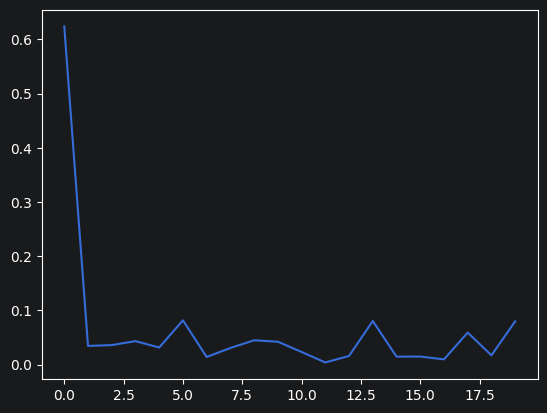

In [31]:
epochs = 20
lr=0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []
for epoch in range(epochs):
    losses.append(train_epoch(model, dl_train, optimizer, epoch+1, device=device))

plt.plot(losses)
(acc, cls) = evaluate_model(model, dl_test, device=device)
print(acc)
print(cls)

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

 Procederò con l'utilizzo del jupyter notebook per la comodità del commento (modulerò come se fosse un python modulo ad eccezione che al posto della config.yaml sarà presente un file o codice python che li gestisce)

## Import utili

In [32]:
import os
import glob
import logging
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, Dataset
from torchvision.models import list_models, get_model
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torchinfo import summary
from rich.console import Console
from rich.logging import RichHandler
import torchvision.utils as vutils
import wandb
import getpass
from types import SimpleNamespace
from ipdb import launch_ipdb_on_exception
from torch.utils.tensorboard import SummaryWriter

## Visualizzazione
fornisco funzioni per la visualizzazione del modello parametri e visualizzazione dataset

In [33]:
# stampa la struttura del modello e numero dei parametri
console = Console()
def visualize(model: nn.Module, model_name: str, input_data: torch.Tensor):
    out = model(input_data)
    console.print(f'Computed output, shape = {out.shape=}')
    model_stats = summary(model,
                          input_data=input_data,
                          col_names=[
                              "input_size",
                              "output_size",
                              "num_params",
                              # "params_percent",
                              # "kernel_size",
                              # "mult_adds",
                          ],
                          row_settings=("var_names",),
                          col_width=18,
                          depth=8,
                          verbose=0,
                          )
    console.print(model_stats)

#mostra le immagini di un campione del dataset
def visualize_dt(sample: list[torch.Tensor]):
    plt.figure(figsize=(15,20))
    for (idx, (image, label)) in enumerate(image_sample):
        plt.subplot(10,10,idx+1)
        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"CLS: {label}")
        plt.axis('off')

## Analisi dati
qui sono presenti le funzioni usate nell'es precedente per l'analisi dati del dataset. Di solito essendo di analisi esplorativa di pre-processing non saranno presenti nella pipeline di lavoro

In [34]:
# funzione per prendere un sottocampione
def getSample(ds_train: torch.utils.data.DataLoader, num_sample: int = 100, ):
    image_sample = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_sample)]
    return image_sample

# funzione per creare un dataframe di pandas da un dataloader (bug se si inserisce più nomi di tre)
def createDataFrame(ds_train: torch.utils.data.DataLoader, column_names: list[str]= ["CLS", "HEIGHT", "WIDTH"], ar: bool= True):
    if len(column_names) == 0 or len(column_names) > 3:
        print("Errore: servono esattamente 1-3 colonne.")
        return None
    df_stats = pd.DataFrame([(label, image.shape[1], image.shape[2]) for (image, label) in ds_train], columns=column_names)
    if ar:
        df_stats["AR"] = df_stats["HEIGHT"] / df_stats["WIDTH"] # colonna aspetto-ratio
    return df_stats

def createGraph(df: pd.DataFrame, type: str="hist"):
    if type == "hist":
        return df.hist()
    elif type == "boxplot":
        return df.boxplot()
    elif type == "violin":
        fig, ax = plt.subplots()
        sns.violinplot(data=df, ax=ax)
        return ax
    elif type == "heatmap":
        plt.figure(figsize=(10, 8))
        # Calcoliamo la correlazione e creiamo il grafico
        sns.heatmap(df_stats.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Analisi Correlazione Dimensioni Immagini")
        plt.show()
    else:
        print("invalid input")




## Dataset
sarà presente solo la classe makedataloader perché non è necessario creare una classe dataset dato che il dataset lo prendiamo direttamente da torchvision

In [35]:
# funzione che crea i dataloader di training e validation
class MakeDataloaders:
    def __init__(self, opts, data):
        self.opts = opts
        generator = torch.Generator().manual_seed(opts.seed)
        train, val = torch.utils.data.random_split(data, lengths=[1 - opts.val_size, opts.val_size],
                                                    generator=generator)
        self.dl_train = DataLoader(train, batch_size=opts.batch_size, shuffle=True, num_workers= opts.num_workers, pin_memory=True)
        self.dl_val = DataLoader(val, batch_size=opts.batch_size, shuffle=False, pin_memory=True, num_workers=True)

def get_transform(opts): # trasform solo per valori di resnet imagenet
    return T.Compose([T.Resize(opts.resize_size), T.RandomCrop((opts.crop_size, opts.crop_size)), T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])



## Model


In [ ]:
class PersonalCNN(nn.Module):
    """CNN semplice per il dataset GTSRB (immagini piccole)."""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),  # output 64x1x1, indipendente dalla size in input
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [36]:
def get_pretrained_model(opts):
    model = get_model(opts.model_name, weights="DEFAULT")
    if opts.freeze_model:
        for param in model.parameters():
            param.requires_grad_(False)
    if opts.freeze_specific_layer:
        for name, param in model.named_parameters():
            if opts.freeze_specific_layer in name:  # o qualsiasi nome del layer
                param.requires_grad = False
    # Recupera l'ultimo modulo e la sua dimensione di input
    last_layer_name, last_layer = list(model.named_children())[-1]
    if isinstance(last_layer, nn.Linear):
        in_features = last_layer.in_features
    elif isinstance(last_layer, nn.Sequential):
        in_features = last_layer[-1].in_features
    else:
        raise ValueError(f"Tipo di layer non gestito: {type(last_layer)}")
    # Sostituisce dinamicamente l'head con Identity
    setattr(model, last_layer_name, nn.Sequential(nn.Linear(in_features, 1024), nn.ReLU(), nn.Linear(1024, 512), nn.ReLU(),
                                                  nn.Linear(512, opts.num_classes),))
    model.to(opts.device)
    return model

def get_personal_model(opts):
    """Crea un modello personalizzato (CNN semplice per GTSRB)."""
    model = PersonalCNN(num_classes=opts.num_classes)
    model.to(opts.device)
    return model



## Utils
sono presenti qui funzioni che non rientrano in particolari categorie, ma hanno lo scopo di helper (non detto che servano sempre)

In [37]:
def get_logger():
    """
    Crea e configura un logger con output colorato usando Rich.
    Utile per stampare messaggi formattati durante il training.
    """
    FORMAT = "%(message)s"
    logging.basicConfig(
        level="NOTSET", format=FORMAT, datefmt="[%X]", handlers=[RichHandler()]
    )
    log = logging.getLogger("rich")
    return log


LOG = get_logger()

## CUDA Check

In [38]:
print("PyTorch loaded from:", torch.__file__)
print("NumPy loaded from:", np.__file__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Torch version: ", torch.__version__)

PyTorch loaded from: C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\torch\__init__.py
NumPy loaded from: C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\numpy\__init__.py
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
Torch version:  2.10.0+cu128


## WANDB
ho riscontrato diversi problemi nell'utilizzo di wandb e quindi sono passato a tensorboard

### Login a wandb

In [39]:
#api_key = getpass.getpass("Inserisci la tua WandB API key: ")
#wandb.login(key=api_key)

### Inizializzazione run

In [40]:


# # da valutare se salvare tutti questi dati o se devo salvarne altri
# def defineRun(opts):
#     config = {
#         "learning_rate": opts.learning_rate,
#         "model-name": opts.model_name,
#         "dataset": opts.dataset,
#         "epochs": opts.epochs,
#         "batch_size": opts.batch_size,
#         "optimizer": opts.optimizer,
#         "scheduler": opts.scheduler,
#         "loss": opts.loss,
#     }
#
#     if opts.momentum and opts.weight_decay: # estendibile
#         config["momentum"] = opts.momentum
#         config["weight_decay"] = opts.weight_decay
#
#     run = wandb.init(
#         entity="lorenzomariapennelli-",
#         project="lab1",
#         config=config,
#     )
#     return run

## Tensorboard

### inizializzazione run

In [41]:

def defineRun(opts):
    """
    Crea una SummaryWriter di TensorBoard.
    Sostituisce wandb.init().
    I log vengono salvati in runs/<model_name>_<optimizer>_lr<lr>
    """
    run_name = f"{opts.model_name}_{opts.optimizer}_lr{opts.learning_rate}"
    log_dir = os.path.join("runs", run_name)
    writer = SummaryWriter(log_dir=log_dir)

    # Logga gli iperparametri come testo
    hparams = {
        "learning_rate": opts.learning_rate,
        "model_name":    opts.model_name,
        "dataset":       opts.dataset,
        "epochs":        opts.epochs,
        "batch_size":    opts.batch_size,
        "optimizer":     opts.optimizer,
        "scheduler":     opts.scheduler,
        "loss":          opts.loss,
        "weight_decay":  opts.weight_decay if opts.weight_decay is not None else 0,
        "gamma":         opts.gamma,
    }
    writer.add_text("hparams", str(hparams), global_step=0)
    LOG.info(f"TensorBoard logging in: {log_dir}")
    return writer

## Testing

In [42]:
# inference functions
def inference_model(model: nn.Module, dl: torch.utils.data.DataLoader , device="cpu", checkpoint_path=None):
    # if checkpoint_path:
    #     model = load_checkpoint(model, optimizer=None, scheduler=None,
    #                             opts=SimpleNamespace(device=device, checkpoint_dir=os.path.dirname(checkpoint_path)),
    #                             checkpoint_path=checkpoint_path)
    model.eval()
    preds = []
    gts = []
    with torch.no_grad():
        for (xs, ys) in tqdm(dl, desc=f"Evaluating", leave=False):
            xs = xs.to(device)
            pred = torch.argmax(model(xs), dim=1)
            gts.append(ys)
            preds.append(pred.detach().cpu().numpy())

        #return accuracy score and classification report
        return (accuracy_score(np.hstack(gts), np.hstack(preds))), classification_report(np.hstack(gts), np.hstack(preds), zero_division=0, digits=1)



## Training

qui verrà inserito il loop di training e valutazione delle prestazioni del modello sia in training che in validazione

In [43]:
def test_metrics(model, val, opts): # calcolo l'accuratezza
    # 1. Imposta il modello in modalità valutazione
    model.eval()

    correct = []

    # 2. Disabilita il calcolo dei gradienti
    with torch.no_grad():
        for Xcpu, Y in val:
            X = Xcpu.to(opts.device)
            Y = Y.to(opts.device)
            out = model(X)

            # Calcolo dell'accuratezza (corretto per Label Encoding)
            # np.argmax(N(out), axis=1) -> Indice predetto
            # N(Y) -> Indice vero
            predictions = out.argmax(dim=1)

            c = (predictions == Y).cpu().tolist()
            correct.extend(c)

    return np.mean(correct)

def train_loop(model, train, test, opts):
    run=defineRun(opts) # definisco la sessione per il mio training loop

    # Weight decay di default
    if opts.weight_decay is None:
        weight_decay = 0.001 if opts.optimizer == "AdamW" else 0
    else:
        weight_decay = opts.weight_decay

    momentum = opts.momentum if opts.momentum is not None else 0

    # optimizer (questa parte dipende da quanti optimizer vogliamo testare e che parametri)
    if opts.optimizer == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(), lr=opts.learning_rate,
            momentum=momentum, weight_decay=weight_decay
        )
    elif opts.optimizer == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(), lr=opts.learning_rate,
            weight_decay=weight_decay
        )
    elif opts.optimizer == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=opts.learning_rate,
            weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Optimizer non valido: {opts.optimizer}")


    # scheduler
    # stesso concetto if in base a quanti scheduler testare
    # per una questione di semplicità ci sarà scritto solo uno
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=opts.gamma)

    #funzioni di loss
    #si basa sempre al contesto dato che il nostro obiettivo è la classificazione solo cross entropy
    loss_fn = torch.nn.CrossEntropyLoss()
    step = 0

    start_epoch = 1
    global_step = 0

    # tralasciamo per ora la precisione mista grazie a gradscaler()

    # if opts.resume: # caricare i checkpoint
    #     checkpoint = load_checkpoint(model, optimizer, scheduler, opts)
    #     if checkpoint is not None:
    #         global_step = checkpoint.get('global_step', 0)
    #         start_epoch = checkpoint['epoch'] + 1

    step = global_step

    LOG.info(f" Training da epoca {start_epoch} a {opts.epochs} | Step: {step}")
    for epoch in range(start_epoch, opts.epochs + 1):
        model.train()
        losses = []
        correct = []
        batch_idx = 0
        for Xcpu, Y in train:
            batch_idx += 1
            X = Xcpu.to(opts.device)
            Y = Y.to(opts.device)
            optimizer.zero_grad()
            out = model(X)
            loss = loss_fn(out, Y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            c = (out.detach().argmax(dim=1) == Y).float().mean().item() # altrimenti N() o mantengo tutto su pytorch
            correct.append(c)
            if batch_idx % opts.log_every == 0:
                train_l = np.mean(losses[-opts.batch_window:])
                train_a = np.mean(correct[-opts.batch_window:])
                test_a = test_metrics(model, test, opts)
                msg = f'{epoch:03d}.{batch_idx:03d}: '
                msg += f'train: loss={train_l:1.6f}, acc={train_a:1.3f} '
                msg += f'test: acc={test_a:1.3f}'
                LOG.info(msg)

                # run.log({
                #     "train/loss": train_l,
                #     "train/accuracy": train_a,
                #     "test/accuracy": test_a,
                #     "learning_rate": optimizer.param_groups[0]['lr'],
                #     "epoch": epoch,
                #     "step": step,
                # })
                # ── TensorBoard logging (sostituisce run.log) ──
                run.add_scalar('train/loss',     train_l, step)
                run.add_scalar('train/accuracy', train_a, step)
                run.add_scalar('val/accuracy',  test_a,  step)
                run.add_scalar('learning_rate',  optimizer.param_groups[0]['lr'], step)
                step += 1

        # if epoch % opts.save_every == 0:
        #     save_checkpoint(model, optimizer, scheduler, epoch, loss, opts)
        scheduler.step()
        LOG.info(f"Epoch {epoch} | LR: {scheduler.get_last_lr()}")

    #run.finish()
    run.close()




def main(opts):
    # Parametri del modello
    input_size = opts.image_size  # Dimensione immagini (224x224 pixel)
    input_data = torch.randn(opts.batch_size, 3, input_size, input_size).to(opts.device)  # Dati fake per visualizzazione
    num_classes = opts.num_classes

    # Crea modello
    if opts.personalized:
        model = get_personal_model(opts)
    else:
        model = get_pretrained_model(opts)

    # Visualizza architettura (salva grafo del modello)
    visualize(model, opts.model_name, input_data)

    # Sposta modello su GPU se disponibile
    model = model.to(opts.device)

    transform = get_transform(opts)

    ds_train = GTSRB("_data/.", split="train", transform=transform, download=True)

    dec = MakeDataloaders(opts, ds_train)
    train = dec.dl_train
    val = dec.dl_val

    ds_test = GTSRB("_data/.", split="test", transform=transform, download=True)
    # test dataloader
    dl_test = DataLoader(ds_test, batch_size=opts.batch_size, shuffle=False)

    # Avvia training
    train_loop(model, train, val, opts)

    if opts.testON:
        (acc, cls)=inference_model(model, dl_test, opts.device, opts.checkpoint_dir)
        print(acc)
        print(cls)





## Configurazione

## MAIN PIPELINE


In [44]:

config = {
    # Modello
    "model_name":       "resnet18",   # nome del modello torchvision
    "personalized":     False,        # True = usa get_personal_model()
    "num_classes":      43,           # GTSRB ha 43 classi
    "freeze_model":     False,        # freeze di tutto il modello
    "freeze_specific_layer": None,    # freeze di uno specifico layer
    "hidden_channels": [256, 128],  # layer nascosti del MLP
    "mlp_dropout": 0.1,             # dropout rate
    # Immagini
    "image_size":       64,          # dimensione input del modello
    "resize_size":      70,          # resize prima del crop
    "crop_size":        64,          # dimensione del random crop

    # Dataset / Split
    "dataset":          "GTSRB",
    "val_size":         0.2,          # frazione di train usata per validation
    "seed":             1234,

    # Dataloader
    "batch_size":       1024,
    "num_workers":      4,

    # Ottimizzatore
    "optimizer":        "AdamW",      # "SGD" | "Adam" | "AdamW"
    "learning_rate":    2e-4,
    "weight_decay":     5e-4,
    "momentum":         None,         # usato solo con SGD

    # Scheduler
    "scheduler":        "ExponentialLR",
    "gamma":            0.95,         # decay factor per ExponentialLR

    # Loss
    "loss":             "CrossEntropyLoss",

    # Training
    "epochs":           10,
    "log_every":        5,           # log ogni N batch
    "batch_window":     5,           # finestra mobile per media loss/acc
    "save_every":       5,            # salva checkpoint ogni N epoche
    "checkpoint_dir":   "checkpoints/resnet18",
    "resume":           False,        # True = riprendi da ultimo checkpoint

    # Testing
    "testON": True                    # abilità il testing
}

In [45]:
# Converte dict config in oggetto SimpleNamespace
opts = SimpleNamespace(**config)

# Usa GPU se disponibile, altrimenti CPU
opts.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# launch_ipdb_on_exception: se c'è un errore, apre debugger invece di crashare
with launch_ipdb_on_exception():
     main(opts)

Computed output, shape = out.shape=torch.Size([1024, 43])

==============================================================================================
Layer (type (var_name))                  Input Shape        Output Shape       Param #
==============================================================================================
ResNet (ResNet)                          [1024, 3, 64, 64]  [1024, 43]         --
├─Conv2d (conv1)                         [1024, 3, 64, 64]  [1024, 64, 32, 32] 9,408
├─BatchNorm2d (bn1)                      [1024, 64, 32, 32] [1024, 64, 32, 32] 128
├─ReLU (relu)                            [1024, 64, 32, 32] [1024, 64, 32, 32] --
├─MaxPool2d (maxpool)                    [1024, 64, 32, 32] [1024, 64, 16, 16] --
├─Sequential (layer1)                    [1024, 64, 16, 16] [1024, 64, 16, 16] --
│    └─BasicBlock (0)                    [1024, 64, 16, 16] [1024, 64, 16, 16] --
│    │    └─Conv2d (conv1)               [1024, 64, 16, 16] [1024, 64, 16, 16] 36,864
│    │    └─BatchNorm2d (bn1)            [1024, 64, 16, 16] [1024, 64, 16, 16] 128
│    │    └─ReLU (relu)                  [1024, 64, 16, 16] [1024, 64, 16, 16] --
│    │    └─Conv2d (conv2)               [1024, 64, 16, 16] [1024, 64, 16, 16] 36,864
│    │    └─BatchNorm2d (bn2)            [1024, 64, 16, 16] [1024, 64, 16, 16] 128
│    │    └─ReLU (relu)                  [1024, 64, 16, 16] [1024, 64, 16, 16] --
│    └─BasicBlock (1)                    [1024, 64, 16, 16] [1024, 64, 16, 16] --
│    │    └─Conv2d (conv1)               [1024, 64, 16, 16] [1024, 64, 16, 16] 36,864
│    │    └─BatchNorm2d (bn1)            [1024, 64, 16, 16] [1024, 64, 16, 16] 128
│    │    └─ReLU (relu)                  [1024, 64, 16, 16] [1024, 64, 16, 16] --
│    │    └─Conv2d (conv2)               [1024, 64, 16, 16] [1024, 64, 16, 16] 36,864
│    │    └─BatchNorm2d (bn2)            [1024, 64, 16, 16] [1024, 64, 16, 16] 128
│    │    └─ReLU (relu)                  [1024, 64, 16, 16] [1024, 64, 16, 16] --
├─Sequential (layer2)                    [1024, 64, 16, 16] [1024, 128, 8, 8]  --
│    └─BasicBlock (0)                    [1024, 64, 16, 16] [1024, 128, 8, 8]  --
│    │    └─Conv2d (conv1)               [1024, 64, 16, 16] [1024, 128, 8, 8]  73,728
│    │    └─BatchNorm2d (bn1)            [1024, 128, 8, 8]  [1024, 128, 8, 8]  256
│    │    └─ReLU (relu)                  [1024, 128, 8, 8]  [1024, 128, 8, 8]  --
│    │    └─Conv2d (conv2)               [1024, 128, 8, 8]  [1024, 128, 8, 8]  147,456
│    │    └─BatchNorm2d (bn2)            [1024, 128, 8, 8]  [1024, 128, 8, 8]  256
│    │    └─Sequential (downsample)      [1024, 64, 16, 16] [1024, 128, 8, 8]  --
│    │    │    └─Conv2d (0)              [1024, 64, 16, 16] [1024, 128, 8, 8]  8,192
│    │    │    └─BatchNorm2d (1)         [1024, 128, 8, 8]  [1024, 128, 8, 8]  256
│    │    └─ReLU (relu)                  [1024, 128, 8, 8]  [1024, 128, 8, 8]  --
│    └─BasicBlock (1)                    [1024, 128, 8, 8]  [1024, 128, 8, 8]  --
│    │    └─Conv2d (conv1)               [1024, 128, 8, 8]  [1024, 128, 8, 8]  147,456
│    │    └─BatchNorm2d (bn1)            [1024, 128, 8, 8]  [1024, 128, 8, 8]  256
│    │    └─ReLU (relu)                  [1024, 128, 8, 8]  [1024, 128, 8, 8]  --
│    │    └─Conv2d (conv2)               [1024, 128, 8, 8]  [1024, 128, 8, 8]  147,456
│    │    └─BatchNorm2d (bn2)            [1024, 128, 8, 8]  [1024, 128, 8, 8]  256
│    │    └─ReLU (relu)                  [1024, 128, 8, 8]  [1024, 128, 8, 8]  --
├─Sequential (layer3)                    [1024, 128, 8, 8]  [1024, 256, 4, 4]  --
│    └─BasicBlock (0)                    [1024, 128, 8, 8]  [1024, 256, 4, 4]  --
│    │    └─Conv2d (conv1)               [1024, 128, 8, 8]  [1024, 256, 4, 4]  294,912
│    │    └─BatchNorm2d (bn1)            [1024, 256, 4, 4]  [1024, 256, 4, 4]  512
│    │    └─ReLU (relu)                  [1024, 256, 4, 4]  [1024, 256, 4, 4]  --
│    │    └─Conv2d (conv2)               [1024, 256, 4, 4]  [1024, 256, 4, 4]  589,824
│    │    └─BatchNorm2d (bn2)            [1024, 256, 

[11:03:30] INFO     TensorBoard logging in: runs\resnet18_AdamW_lr0.0002                           ]8;id=672060;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\1637745850.py\1637745850.py]8;;\:]8;id=967670;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\1637745850.py#25\25]8;;\

           INFO      Training da epoca 1 a 10 | Step: 0                                            ]8;id=714298;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=327309;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#78\78]8;;\

[11:03:43] INFO     001.005: train: loss=3.491319, acc=0.143 test: acc=0.180                      ]8;id=129376;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=528126;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:03:49] INFO     001.010: train: loss=2.654338, acc=0.291 test: acc=0.427                      ]8;id=214028;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=691684;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:03:55] INFO     001.015: train: loss=1.813446, acc=0.488 test: acc=0.579                      ]8;id=933325;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=754805;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:04:01] INFO     001.020: train: loss=1.266998, acc=0.612 test: acc=0.635                      ]8;id=504394;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=144529;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

           INFO     Epoch 1 | LR: [0.00019]                                                       ]8;id=503698;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=621961;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:04:16] INFO     002.005: train: loss=2.257349, acc=0.574 test: acc=0.434                      ]8;id=662391;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=618539;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:04:22] INFO     002.010: train: loss=1.677388, acc=0.528 test: acc=0.580                      ]8;id=112291;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=66214;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:04:28] INFO     002.015: train: loss=1.045009, acc=0.659 test: acc=0.711                      ]8;id=530281;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=124384;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:04:34] INFO     002.020: train: loss=0.708765, acc=0.757 test: acc=0.794                      ]8;id=240884;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=630005;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:04:35] INFO     Epoch 2 | LR: [0.0001805]                                                     ]8;id=969496;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=38068;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:04:49] INFO     003.005: train: loss=1.337497, acc=0.722 test: acc=0.681                      ]8;id=659320;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=215665;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:04:55] INFO     003.010: train: loss=0.672572, acc=0.778 test: acc=0.835                      ]8;id=877443;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=85994;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:01] INFO     003.015: train: loss=0.433932, acc=0.848 test: acc=0.890                      ]8;id=365522;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=509837;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:07] INFO     003.020: train: loss=0.285242, acc=0.905 test: acc=0.912                      ]8;id=248108;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=178902;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:08] INFO     Epoch 3 | LR: [0.00017147499999999998]                                        ]8;id=839011;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=108830;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:05:22] INFO     004.005: train: loss=0.781623, acc=0.842 test: acc=0.802                      ]8;id=272556;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=279968;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:28] INFO     004.010: train: loss=0.336745, acc=0.885 test: acc=0.916                      ]8;id=193278;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=858344;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:33] INFO     004.015: train: loss=0.203788, acc=0.931 test: acc=0.939                      ]8;id=390433;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=391081;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:39] INFO     004.020: train: loss=0.155609, acc=0.948 test: acc=0.955                      ]8;id=67254;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=183794;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:05:40] INFO     Epoch 4 | LR: [0.00016290124999999997]                                        ]8;id=367602;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=914030;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:05:55] INFO     005.005: train: loss=0.425416, acc=0.942 test: acc=0.882                      ]8;id=163783;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=80387;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:02] INFO     005.010: train: loss=0.174567, acc=0.941 test: acc=0.957                      ]8;id=331903;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=225529;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:09] INFO     005.015: train: loss=0.103474, acc=0.968 test: acc=0.973                      ]8;id=152059;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=877944;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:15] INFO     005.020: train: loss=0.077970, acc=0.974 test: acc=0.979                      ]8;id=917360;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=475513;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:16] INFO     Epoch 5 | LR: [0.00015475618749999996]                                        ]8;id=855189;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=623138;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:06:31] INFO     006.005: train: loss=0.246558, acc=0.967 test: acc=0.899                      ]8;id=633260;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=70699;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:38] INFO     006.010: train: loss=0.164586, acc=0.944 test: acc=0.975                      ]8;id=779638;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=762320;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:44] INFO     006.015: train: loss=0.097847, acc=0.970 test: acc=0.971                      ]8;id=112504;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=239776;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:51] INFO     006.020: train: loss=0.074385, acc=0.977 test: acc=0.977                      ]8;id=264354;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=77660;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:06:52] INFO     Epoch 6 | LR: [0.00014701837812499996]                                        ]8;id=720563;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=835273;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:07:07] INFO     007.005: train: loss=0.145786, acc=0.983 test: acc=0.971                      ]8;id=499525;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=465484;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:07:14] INFO     007.010: train: loss=0.044052, acc=0.985 test: acc=0.983                      ]8;id=884816;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=186492;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:07:20] INFO     007.015: train: loss=0.031723, acc=0.991 test: acc=0.986                      ]8;id=152683;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=838140;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:07:27] INFO     007.020: train: loss=0.025337, acc=0.990 test: acc=0.989                      ]8;id=641395;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=867824;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:07:28] INFO     Epoch 7 | LR: [0.00013966745921874994]                                        ]8;id=929977;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=78188;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:07:43] INFO     008.005: train: loss=0.095056, acc=0.988 test: acc=0.981                      ]8;id=228949;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=471571;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:07:50] INFO     008.010: train: loss=0.026013, acc=0.993 test: acc=0.989                      ]8;id=317202;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=613538;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:07:57] INFO     008.015: train: loss=0.019441, acc=0.995 test: acc=0.990                      ]8;id=971988;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=924235;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:03] INFO     008.020: train: loss=0.014969, acc=0.995 test: acc=0.989                      ]8;id=267584;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=395164;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:04] INFO     Epoch 8 | LR: [0.00013268408625781244]                                        ]8;id=550246;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=55277;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:08:18] INFO     009.005: train: loss=0.063731, acc=0.995 test: acc=0.987                      ]8;id=491603;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=6129;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:25] INFO     009.010: train: loss=0.015247, acc=0.996 test: acc=0.992                      ]8;id=428482;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=31630;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:31] INFO     009.015: train: loss=0.016189, acc=0.995 test: acc=0.992                      ]8;id=119600;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=523950;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:37] INFO     009.020: train: loss=0.009115, acc=0.997 test: acc=0.991                      ]8;id=385592;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=522744;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:38] INFO     Epoch 9 | LR: [0.0001260498819449218]                                         ]8;id=646586;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=390098;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

[11:08:53] INFO     010.005: train: loss=0.047141, acc=0.998 test: acc=0.991                      ]8;id=234606;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=385267;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:08:59] INFO     010.010: train: loss=0.008793, acc=0.999 test: acc=0.994                      ]8;id=217503;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=792767;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:09:05] INFO     010.015: train: loss=0.007444, acc=0.998 test: acc=0.994                      ]8;id=296317;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=623040;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:09:11] INFO     010.020: train: loss=0.008536, acc=0.997 test: acc=0.994                      ]8;id=84287;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=419616;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#103\103]8;;\

[11:09:12] INFO     Epoch 10 | LR: [0.00011974738784767572]                                       ]8;id=361177;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py\2580247420.py]8;;\:]8;id=478855;file://C:\Users\Utente\AppData\Local\Temp\ipykernel_21576\2580247420.py#123\123]8;;\

0.9419635787806809
              precision    recall  f1-score   support

           0        1.0       0.8       0.8        60
           1        0.9       0.9       0.9       720
           2        0.9       0.9       0.9       750
           3        0.9       0.9       0.9       450
           4        1.0       1.0       1.0       660
           5        0.9       0.9       0.9       630
           6        1.0       1.0       1.0       150
           7        0.9       1.0       1.0       450
           8        0.9       0.9       0.9       450
           9        1.0       1.0       1.0       480
          10        1.0       1.0       1.0       660
          11        1.0       0.9       0.9       420
          12        1.0       1.0       1.0       690
          13        1.0       1.0       1.0       720
          14        1.0       0.9       1.0       270
          15        0.9       1.0       1.0       210
          16        1.0       1.0       1.0       150
        

## Visualizzazione tensorboard (only jupyter)

Per il command line: tensorboard --logdir=Lab1\runs

*Per una questione di gestione memoria che con pycharm crasha questa cella è commentata , ma in teoria funziona*

In [46]:
#%load_ext tensorboard
#%tensorboard --logdir runs

## Pipeline Testing

In [47]:
# semplici funzioni di testing

(acc, cls)=inference_model(model, dl_test, opts.device, opts.checkpoint_dir)
print(acc)
print(cls)

0.9158353127474268
              precision    recall  f1-score   support

           0        0.8       1.0       0.9        60
           1        0.9       1.0       0.9       720
           2        1.0       1.0       1.0       750
           3        0.9       1.0       0.9       450
           4        1.0       1.0       1.0       660
           5        1.0       0.9       0.9       630
           6        1.0       0.9       1.0       150
           7        0.9       1.0       1.0       450
           8        1.0       0.9       0.9       450
           9        1.0       1.0       1.0       480
          10        1.0       1.0       1.0       660
          11        0.9       1.0       0.9       420
          12        1.0       1.0       1.0       690
          13        1.0       1.0       1.0       720
          14        1.0       0.9       0.9       270
          15        0.9       1.0       1.0       210
          16        1.0       1.0       1.0       150
        


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [48]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [49]:
import os
import glob
import logging
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, Dataset
from torchvision.models import list_models, get_model
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score
from torchinfo import summary
from rich.console import Console
from rich.logging import RichHandler
from types import SimpleNamespace
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import precision_recall_curve, average_precision_score
from torchvision import models
from pytorch_metric_learning.utils.accuracy_calculator import AccuracyCalculator
from sklearn.decomposition import PCA

[11:09:31] DEBUG    Environment variable FAISS_OPT_LEVEL is not set, so let's pick the instruction set ]8;id=251522;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\faiss\loader.py\loader.py]8;;\:]8;id=977021;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\faiss\loader.py#96\96]8;;\
                    according to the current CPU                                                                   

           INFO     Loading faiss with AVX2 support.                                                  ]8;id=213568;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\faiss\loader.py\loader.py]8;;\:]8;id=262051;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\faiss\loader.py#132\132]8;;\

           INFO     Successfully loaded faiss with AVX2 support.                                      ]8;id=994679;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\faiss\loader.py\loader.py]8;;\:]8;id=959658;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\faiss\loader.py#134\134]8;;\

Per prima cosa voglio osservare meglio il dataset in particolare capire quanti elementi sono presenti per ogni classe

per l'analisi prendiamo il dataset senza trasformazioni particolari dato che dipenderanno dal tipo di backbone useremo

In [50]:
# versione senza warning
transform = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

ds_train = GTSRB("_data/.", split="train", transform=transform, download=False)
ds_test = GTSRB("_data/.", split="test", transform=transform, download=False)

train_labels = [label for _, label in ds_train._samples]

# conteggio degli elementi per classe (train)
df = pd.DataFrame({
    "N_Images": pd.Series(train_labels).value_counts().sort_index().values,
})


In [51]:
df

,N_Images
0,150
1,1500
2,1500
3,960
4,1320
5,1260
6,300
7,960
8,960
9,990


<Axes: >

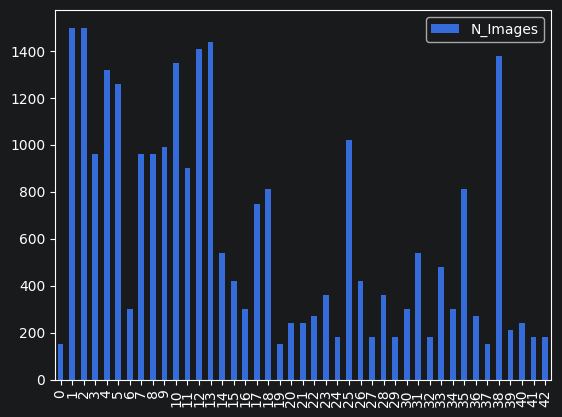

In [52]:
df.plot.bar()

### Osservazioni:
- la prima cosa che notiamo che nel dataset "training" ogni classe non ha lo stesso numero di esempi e il massimo numero raggiungibile è 1500 esempi e il minimo è 150. Teniamolo presente perché questo sbilanciamento potrebbe influire sulla prestazioni di similarità soprattutto per le classi con poche immagini.

- notiamo soprattutto dagli studi effettuati precedentemente una varianza sulle dimensioni delle immagini che deve essere ovviamente gestita con l'utilizzo di trasformazioni che portano alla stessa dimensione

- presta attenzione che con la trasformazione cambia solo l'immagine in tensore, la classe (label) rimane un valore intero

---

## IDEA Procedimento
- Usare backbone cnn
    - VGG (layer6)  --*dal paper*
    - ResNet50 (valutazione tra diversi layer) + GeM (p=3)  --*dal paper*
    - ViT (cls token)
    - DINOv2 (cls token)   --*dal paper*
- possibile compressione PCA (attenziona all'utilizzarla)
- L2 normalization --*dal paper*
- Cosine Similarity --*dal paper* (come ulteriore conferma vista a lezione di data-mining per il clustering)
- metrica di valutazione mPA --*dal paper*
- realizzazione del NMC

In [53]:
back = get_model("vgg11", weights="DEFAULT")
print(back)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

### GEM Class (from paper)

In [54]:
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6, trainable=False):
        super().__init__()
        if trainable:
            self.p = nn.Parameter(torch.ones(1) * p)
        else:
            self.p = p  # fisso, non apprendibile
        self.eps = eps

    def forward(self, x):
        p = self.p if isinstance(self.p, (int, float)) \
            else self.p.item()
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(p),
            output_size=1
        ).pow(1.0 / p)

sappiamo che dal paper il migliore risultato sia circa 3 quindi dato che non devo addestrare imposto quel valore
$$
f_k = \left(\frac{1}{|X_k|} \sum_{x \in X_k} x^p\right)^{1/p}
$$

### Function to choose the right trasform to images

In [55]:

def define_transform(opts):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if opts.backbone_name == "resnet50":
        return T.Compose([
            T.Resize((224, 224),
                     interpolation=T.InterpolationMode.BICUBIC,
                     antialias=True),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=mean, std=std)
        ])

    elif opts.backbone_name == "vit_b_16":
        return T.Compose([
            T.Resize((248, 248),
                     interpolation=T.InterpolationMode.BICUBIC,
                     antialias=True),
            T.CenterCrop(224),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=mean, std=std)
        ])

    elif opts.backbone_name == "DinoV2":
        return T.Compose([
            T.Resize((224, 224),
                     interpolation=T.InterpolationMode.BICUBIC,
                     antialias=True),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=mean, std=std)
        ])

    else:
        return T.Compose([
            T.Resize((opts.resize_size, opts.resize_size),
                     interpolation=T.InterpolationMode.BICUBIC,
                     antialias=True),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=mean, std=std)
        ])


### Generic extractor creation function

In [56]:
def mid_layers_resnet50_exct(opts, gem, backbone):
    """ funzione per ottenere del feature del layer interessato del resnet50"""
    # Mappa l'input numerico (1, 2, 3) ai nomi dei blocchi ResNet
    target_map = {
        1: "layer1",
        2: "layer2",
        3: "layer3",
    }
    target_layer = target_map.get(opts.mid_layer_extr)
    if not target_layer:
        raise ValueError(f"Livello {opts.mid_layer_extr} non valido. Scegli tra 1 e 3.")

    new_layers = []
    # Iteriamo sui moduli nominati del backbone
    for name, module in backbone.named_children():
        new_layers.append(module)
        # Quando arriviamo al layer scelto (es. 'layer3'), ci fermiamo
        if name == target_layer:
            break

    # Aggiungiamo i componenti finali per ottenere un vettore (descrittore)
    new_layers.append(gem)         # Pooling (riduce a 1x1)

    return nn.Sequential(*new_layers)


def get_feature_extractor(opts) -> nn.Module:
    """
    Funzione per creare un backbone per estrarre feature e gestisce i casi di estrazione intermedia nel caso di resnet50 (scelgo che livello medio estrarre)
    :param opts:
    :return: nn.Module pronto per estrarre feature
    """
    if opts.backbone_name == "DinoV2": # lo prendo per via del paper in cui afferma che dovrebbe essere il migliore ad estrarre feature
        backbone = torch.hub.load(
            'facebookresearch/dinov2',
            'dinov2_vitb14'  # ViT-Base, CLS token 768-dim
        )
        print(backbone)
    else:
        backbone = get_model(opts.backbone_name, weights="DEFAULT")
        gem = GeM(p=3, eps=1e-6)
        if opts.backbone_name == "resnet50":
            if opts.use_mid_layers:
                 backbone=mid_layers_resnet50_exct(opts, gem, backbone)
            else:
                backbone.avgpool = gem
                backbone.fc = nn.Identity()
        else:
            # Recupera il nome dell'ultimo modulo del backbone
            last_layer_name, _ = list(backbone.named_children())[-1]
            # Sostituisce dinamicamente l'head con Identity
            setattr(backbone, last_layer_name, nn.Identity())
            # if opts.backbone_name == "vgg11":
            #     backbone.avgpool = gem

    return nn.Sequential(
        backbone,
        nn.Flatten() # Appiattisce in un vettore [B, C]
    )

### Generic feature extractror function

In [57]:
def feature_extractor(fe: nn.Module, dl: torch.utils.data.DataLoader, opts) -> tuple[torch.Tensor, torch.Tensor]:
    """In questa funzione assegno un modello e un dataloader e ottengo una tupla di tensori con le label associate"""
    fe.eval()
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(dl):
            images = images.to(opts.device)

            features = fe(images) # estraggo le features [B, C]

            # i paper applicano tutti una normalizzazione l2
            features = F.normalize(features, p=2, dim=1)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_features, dim=0), torch.cat(all_labels, dim=0)

### Cosine Similarity

In [58]:
def compute_similarity(query_features: torch.Tensor, gallery_features: torch.Tensor) -> torch.Tensor:
    # Entrambi già L2-normalizzati
    # cosine similarity = prodotto scalare
    similarity =query_features  @ gallery_features.T    # [M, N] in cui gli score che ci interessano sono le righe
    return similarity

### Evaluate Function

In [59]:
def evaluate_pml(query_features, gallery_features, query_labels, gallery_labels):
    """
    Calcola le metriche usando pytorch-metric-learning come confronto
    alla funzione evaluate() manuale.

    Metriche calcolate:
    - precision_at_1: equivalente alla nostra accuracy (top-1)
    - mean_average_precision: equivalente al nostro mAP
    - mean_average_precision_at_r: mAP troncato a R, penalizza chi trova le immagini rilevanti solo in fondo
    """
    calculator = AccuracyCalculator(
        include=("precision_at_1", "mean_average_precision", "mean_average_precision_at_r"),
        avg_of_avgs=False,   # media per classe poi media delle medie: se TRUE più equo con GTSRB che è sbilanciato
        device=torch.device("cpu")
    )
    return calculator.get_accuracy(
        query=query_features,
        reference=gallery_features,
        query_labels=query_labels,
        reference_labels=gallery_labels,
        ref_includes_query=False  # query (test) e gallery (train) sono separati

    )

def compare_metrics(my_metrics, pml_metrics):
    """
    Stampa un confronto affiancato tra le due implementazioni.
    Utile per verificare la correttezza della nostra evaluate() manuale.
    """
    print("\n" + "="*55)
    print(f"{'Metrica':<30} {'Nostra':>10} {'PML':>10}")
    print("="*55)
    print(f"{'Accuracy (precision@1)':<30} {my_metrics['accuracy']:>10.4f} {pml_metrics['precision_at_1']:>10.4f}")
    print(f"{'mAP':<30} {my_metrics['mAP']:>10.4f} {pml_metrics['mean_average_precision']:>10.4f}")
    print(f"{'mAP@R':<30} {'  N/A':>10} {pml_metrics['mean_average_precision_at_r']:>10.4f}")
    print("="*55)
    print()

def evaluate(score_matrix, query_labels, gallery_labels, n_classes):
    """Funzione per il calcolo dell'accuracy, globale del modello, mAP e curve PR_CURVE"""
    # Calcoliamo l'accuratezza del modello

    # Per ogni query (riga), trova l'indice della gallery con score massimo
    top_indices  = score_matrix.argmax(dim=1)

    # Usa gli indici trovati come "puntatori" dentro gallery_labels per recuperare la classe dell'immagine più simile per ogni query
    top_preds = gallery_labels[top_indices]

    # facciamo un confronto elemento per elemento e convertiamo i risultati di True e false in valori numerici (1,0)
    correct       = (top_preds == query_labels).float()

    #calcoliamo l'accuratezza usando la formula della media e convertiamo da tensor a numero di python
    accuracy      = correct.mean().item()

    # Calcoliamo il mAP usato da molti paper per il confronto delle prestazioni e anche un AP per classe per capire quale è la classe in cui trova più difficoltà

    #calcolo il ranking cioè ordino per ogni query gli score ottenuti in modo discendente
    rankings = torch.argsort(
        score_matrix, dim=1, descending=True
    )  # [M, N]

    #generiamo le liste che collezioneranno le average precision totali e per classi
    aps = []
    aps_classes  = {c: [] for c in range(n_classes)} # dict compressione

    for i in range(len(query_labels)):
        # Riordina le etichette della gallery secondo il ranking della query i
        ranked_labels = gallery_labels[rankings[i]]

        # Vettore binario: 1 dove la gallery ha la stessa classe della query, 0 altrove
        relevant = (ranked_labels == query_labels[i]).float()

        # Conta quante immagini nella gallery appartengono alla stessa classe della query serve per l'AP
        num_relevant = relevant.sum().item()

        if num_relevant == 0:
            continue # per evitare la divisione per zero

        # facciamo la somma comulativa ci interessa sapere quante posizioni rilevanti ho trovato fino a quella posizione
        cumsum = torch.cumsum(relevant, dim=0)

        #Crea un vettore con le posizioni del ranking da 1 a N in float perché ci serve lavorare in float
        positions   = torch.arange(1, len(rankings[i]) + 1).float()

        # Divide elemento per elemento, calcola la precision a ogni posizione k, indica quante delle prime k immagini sono rilevanti
        precision_k = cumsum / positions

        # moltiplica precision_k per relevant, azzerando le posizioni non rilevanti
        prodotto = precision_k * relevant

        somma_rev = prodotto.sum()

        ap = somma_rev / num_relevant

        ap = ap.item() # ci serve per inserire in una lista python

        aps.append(ap)

        #Aggiunge lo stesso AP alla lista della classe corretta nel dizionario.
        aps_classes[query_labels[i].item()].append(ap)

    # calcolo del mAP
    mAP = sum(aps) / len(aps) if aps else 0.0

    # media AP per classe
    mAP_classes ={}
    for key, value in aps_classes.items():
        if value:
            mAP_classes[key] = sum(value) / len(value)


    # Calcola area sotto la curva PR per ogni classe

    # Crea una matrice di zeri [M, 43] dove: ogni riga i = una query del test set, ogni colonna c = una classe (0..42)
    class_scores = torch.zeros(len(query_labels), n_classes)

    # per ognuna calcoleremo lo score "quanto è simile ogni query a questa classe
    for c in range(n_classes):

        mask = (gallery_labels == c)

        if mask.sum() > 0:

            # Seleziona solo le colonne della score_matrix corrispondenti alle immagini di classe c prende il massimo per ogni riga (ogni query) e solo i valori
            class_scores[:, c] = score_matrix[:, mask].max(dim=1).values

    # al fine del ciclo avremo una matrice class_scores[i, c] = score massimo della query i con qualsiasi immagine di classe c nella gallery

    # Crea una matrice numpy di zeri [M, 43] numpy invece di PyTorch perché sklearn non accetta tensori
    y_true_bin = np.zeros((len(query_labels), n_classes))

    for i, label in enumerate(query_labels):
        y_true_bin[i, label] = 1

    try:
        pr_auc = average_precision_score(
            y_true_bin, #  label vere in formato one-hot [M, 43] ogni riga ha un solo 1 nella colonna della classe vera
            class_scores.numpy(), # score predetti [M, 43] in formato numpy
            average='macro', # calcola ROC-AUC per ogni classe separatamente poi fa la media semplice
        )
    except ValueError:
        pr_auc = 0.0

    return {
        "accuracy": accuracy,
        "mAP": mAP,
        "pr_auc": pr_auc,
        "mAP_classes": mAP_classes,
        "rankings": rankings, # me lo porto dietro potrebbe essere utile
        "y_true_bin":   y_true_bin,
        "class_scores": class_scores.numpy()
    }



### Logging and visualize functions

In [60]:
# i plot generati non sono abbastanza informativi
def plot_pr_curves(y_true_bin, class_scores, num_classes=43, writer=None):
    """
    Disegna una curva PR per ogni classe e una media macro.
    """

    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = plt.cm.tab20(np.linspace(0, 1, num_classes))

    ap_scores = []

    for c in range(num_classes):

        # Calcola precision e recall per ogni soglia
        precision, recall, _ = precision_recall_curve(
            y_true_bin[:, c],    # label binarie per classe c
            class_scores[:, c]   # score per classe c
        )

        # Area sotto la curva PR per questa classe
        ap_c = average_precision_score(
            y_true_bin[:, c],
            class_scores[:, c]
        )
        ap_scores.append(ap_c)

        # Disegna la curva — trasparente per non sovraffollare
        ax.plot(
            recall, precision,
            color=colors[c],
            alpha=0.3,
            linewidth=0.8,
            label=f'classe {c:02d} (AP={ap_c:.2f})'
        )

    # Curva media macro
    mean_ap = np.mean(ap_scores)

    # Calcola la curva media interpolando su griglia comune
    mean_recall    = np.linspace(0, 1, 100)
    mean_precision = np.zeros_like(mean_recall)

    for c in range(num_classes):
        precision, recall, _ = precision_recall_curve(
            y_true_bin[:, c],
            class_scores[:, c]
        )
        # Inverti per interpolazione monotona
        mean_precision += np.interp(
            mean_recall,
            recall[::-1],
            precision[::-1]
        )

    mean_precision /= num_classes

    ax.plot(
        mean_recall, mean_precision,
        color='black',
        linewidth=2.5,
        label=f'media macro (AP={mean_ap:.3f})'
    )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curves — GTSRB')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.legend(
        loc='lower left',
        bbox_to_anchor=(1.01, 0),
        fontsize=7,
        ncol=2
    )

    plt.tight_layout()

    if writer:
        writer.add_figure('Plots/PR_curves', fig)




def plot_per_class_ap(per_class_ap, backbone_name, writer=None):

    classes = list(per_class_ap.keys())
    values  = list(per_class_ap.values())
    mean_ap = sum(values) / len(values)

    fig, ax = plt.subplots(figsize=(14, 5))

    # Colora rosso le classi difficili (AP < 0.5)
    colors = [
        '#d62728' if v < 0.5 else '#1f77b4'
        for v in values
    ]

    ax.bar(classes, values, color=colors)
    ax.axhline(
        y=mean_ap,
        color='orange',
        linestyle='--',
        linewidth=1.5,
        label=f'mAP = {mean_ap:.3f}'
    )
    ax.set_xlabel('Classe')
    ax.set_ylabel('AP')
    ax.set_title(f'AP per classe — {backbone_name}')
    ax.set_ylim([0, 1.05])
    ax.legend()
    plt.tight_layout()

    if writer:
        writer.add_figure('Plots/AP_per_class', fig)

    plt.close(fig)


# stampa la struttura del modello e numero dei parametri
console = Console()
def visualize(model: nn.Module, model_name: str, input_data: torch.Tensor):
    out = model(input_data)
    console.print(f'Computed output, shape = {out.shape=}')
    model_stats = summary(model,
                          input_data=input_data,
                          col_names=[
                              "input_size",
                              "output_size",
                              "num_params",
                              # "params_percent",
                              # "kernel_size",
                              # "mult_adds",
                          ],
                          row_settings=("var_names",),
                          col_width=18,
                          depth=8,
                          verbose=0,
                          )
    console.print(model_stats)

### NMC CLassifier

In [61]:
def nmc_classify(gallery_features, gallery_labels, query_features, query_labels, n_classes):
    """
    Nearest Mean Classifier:
    - Calcola il centroide medio per ogni classe dalla gallery
    - Classifica ogni query assegnandola alla classe del centroide più vicino
    """
    # Calcola centroide per ogni classe
    centroids = torch.zeros(n_classes, gallery_features.shape[1])
    for c in range(n_classes):
        mask = (gallery_labels == c)
        if mask.sum() > 0:
            centroids[c] = gallery_features[mask].mean(dim=0)

    # L2 normalize i centroidi
    centroids = F.normalize(centroids, p=2, dim=1)

    # Similarity tra ogni query e ogni centroide [M, 43]
    scores = query_features @ centroids.T

    # Classe predetta = centroide più vicino
    predictions = scores.argmax(dim=1)

    # Metriche
    accuracy = (predictions == query_labels).float().mean().item()

    # AP per classe
    aps_classes = {}
    for c in range(n_classes):
        mask = (query_labels == c)
        if mask.sum() == 0:
            continue
        # Score della classe c per tutte le query
        class_score = scores[:, c]
        # Label binaria: 1 se la query appartiene alla classe c
        binary_labels = (query_labels == c).float()
        ap = average_precision_score(binary_labels.numpy(), class_score.numpy())
        aps_classes[c] = ap

    mAP = sum(aps_classes.values()) / len(aps_classes)

    return {
        "accuracy":    accuracy,
        "mAP":         mAP,
        "aps_classes": aps_classes,
        "centroids":   centroids,
        "scores":      scores,
        "predictions": predictions,
    }

### PCA whitening

In [62]:

def whiten_features(gallery_features, query_features, n_components=None):
    """
    PCA whitening come da Radenovic et al. 2018
    n_components=None mantiene la dimensionalità originale (solo whitening)
    n_components=512 riduce anche la dimensionalità
    """
    pca = PCA(n_components=n_components, whiten=True)

    # Fit SOLO sulla gallery (il training set)
    gallery_w = pca.fit_transform(gallery_features.numpy())

    # Transform sulle query con i parametri della gallery
    query_w = pca.transform(query_features.numpy())

    # Ri-normalizza L2 dopo il whitening
    gallery_w = torch.tensor(gallery_w)
    query_w = torch.tensor(query_w)
    gallery_w = F.normalize(gallery_w, p=2, dim=1)
    query_w = F.normalize(query_w, p=2, dim=1)

    return gallery_w, query_w

## MAIN PIPELINE

### Parametri

In [63]:
config = {
    # Modello
    "model_name":       "vgg_gem_NMC",   # nome del modello che verrà salvato su tensorboard
    "backbone_name":    "vgg11",   # nome del backbone che useremo come estrattore
    "num_classes":      43,           # GTSRB ha 43 classi
    "use_mid_layers":   False,        # se True estraggo dai layer interni del resnet50
    "mid_layer_extr":   2,            # estraggo le feature da quel layer [1,2,3]

    # Immagini
    "image_size":       224,          # dimensione input del modello
    "resize_size":      224,          # resize prima del crop
    "crop_size":        64,          # dimensione del random crop



    # Dataloader
    "batch_size":       16,
    "num_workers":      4,

    #PCA
    "do_PCA":           True,         # se attiva si fa come da paper il PCA whitening (tanto rischio di perdità)
    "n_components":     512,

    #compare
    "do_compare": True,             # se True facciamo una comparazione tra le metriche custom e quelle della libreria
    "nmc": True,                    # se True calcoliamo anche i centroidi e classifichiamo con un NMC
}

### MAIN

In [64]:
# Converte dict config in oggetto SimpleNamespace
opts = SimpleNamespace(**config)

# Usa GPU se disponibile, altrimenti CPU
opts.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Parametri del modello
input_size = opts.image_size  # Dimensione immagini (70x70 pixel)
input_data = torch.randn(opts.batch_size, 3, input_size, input_size).to(opts.device) # Dati fake per visualizzazione

model = get_feature_extractor(opts)
model.to(opts.device)

visualize(model, opts.model_name, input_data)



run_name = f"{opts.model_name}"
log_dir = os.path.join("runs", run_name)
writer = SummaryWriter(log_dir=log_dir)


transform=define_transform(opts)

ds_train = GTSRB("_data/.", split="train", transform=transform, download=True)
dl_train = DataLoader(ds_train, batch_size=opts.batch_size, num_workers=opts.num_workers, shuffle=True, pin_memory=True)

ds_test = GTSRB("_data/.", split="test", transform=transform, download=True)
dl_test = DataLoader(ds_test, batch_size=opts.batch_size, shuffle=False, num_workers=opts.num_workers, pin_memory=True)

gallery_features=[]
gallery_labels=[]

# estraiamo le feature di galleria e salviamo le label
gallery_features, gallery_labels=feature_extractor(model, dl_train, opts)

#estraiamo le query feature e salviamo le label
query_features =[]
query_labels=[]
query_features, query_labels = feature_extractor(model, dl_test, opts)
#print(gallery_features)
#print(gallery_labels)
#print(query_features)
#print(query_labels)


if opts.do_PCA:
    gallery_features, query_features = whiten_features(gallery_features, query_features, n_components=opts.n_components)
#Calcola la media SOLO sulla gallery
#mean = gallery_features.mean(dim=0, keepdim=True)  # [1, 768]

# Applica la stessa media a entrambe
#gallery_features = gallery_features - mean
#query_features = query_features - mean

#gallery_features = F.normalize(gallery_features, p=2, dim=1)
#query_features = F.normalize(query_features, p=2, dim=1)

#print(gallery_features)
#print(gallery_labels)
#print(query_features)
#print(query_labels)

matrix_score = compute_similarity(query_features, gallery_features)
#print(matrix_score)

metrics = evaluate(matrix_score, query_labels, gallery_labels, opts.num_classes)
#print(metrics)
if opts.do_compare:
    pml_metrics = evaluate_pml(query_features=query_features, query_labels=query_labels, gallery_features=gallery_features, gallery_labels=gallery_labels)
    compare_metrics(metrics, pml_metrics)

if opts.nmc:
    nmc_metrics = nmc_classify(
        gallery_features, gallery_labels,
        query_features, query_labels,
        opts.num_classes
    )
    print("\n" + "="*45)
    print(f"{'Metrica':<25} {'Retrieval':>10} {'NMC':>10}")
    print("="*45)
    print(f"{'Accuracy':<25} {metrics['accuracy']:>10.4f} {nmc_metrics['accuracy']:>10.4f}")
    print(f"{'mAP':<25} {metrics['mAP']:>10.4f} {nmc_metrics['mAP']:>10.4f}")
    print("="*45)
    writer.add_scalar('NMC/accuracy',       nmc_metrics['accuracy'])
    writer.add_scalar('NMC/mAP',            nmc_metrics['mAP'])

# disegnamo e salviamo su tensorboard le pr curve
#plot_pr_curves(metrics["y_true_bin"], metrics["class_scores"], writer=writer)

#confronto delle capacità del modello di gestire tutte le classi
plot_per_class_ap(metrics["mAP_classes"], opts.backbone_name, writer=writer)


# Scalari su TensorBoard
writer.add_scalar('Metrics/accuracy', metrics['accuracy'])
writer.add_scalar('Metrics/mAP',      metrics['mAP'])
writer.add_scalar('Metrics/PR_AUC',   metrics['pr_auc'])


writer.close()

print("End retrieval")

Computed output, shape = out.shape=torch.Size([16, 25088])

==============================================================================================
Layer (type (var_name))                  Input Shape        Output Shape       Param #
==============================================================================================
Sequential (Sequential)                  [16, 3, 224, 224]  [16, 25088]        --
├─VGG (0)                                [16, 3, 224, 224]  [16, 25088]        --
│    └─Sequential (features)             [16, 3, 224, 224]  [16, 512, 7, 7]    --
│    │    └─Conv2d (0)                   [16, 3, 224, 224]  [16, 64, 224, 224] 1,792
│    │    └─ReLU (1)                     [16, 64, 224, 224] [16, 64, 224, 224] --
│    │    └─MaxPool2d (2)                [16, 64, 224, 224] [16, 64, 112, 112] --
│    │    └─Conv2d (3)                   [16, 64, 112, 112] [16, 128, 112, 112] 73,856
│    │    └─ReLU (4)                     [16, 128, 112, 112] [16, 128, 112, 112] --
│    │    └─MaxPool2d (5)                [16, 128, 112, 112] [16, 128, 56, 56]  --
│    │    └─Conv2d (6)                   [16, 128, 56, 56]  [16, 256, 56, 56]  295,168
│    │    └─ReLU (7)                     [16, 256, 56, 56]  [16, 256, 56, 56]  --
│    │    └─Conv2d (8)                   [16, 256, 56, 56]  [16, 256, 56, 56]  590,080
│    │    └─ReLU (9)                     [16, 256, 56, 56]  [16, 256, 56, 56]  --
│    │    └─MaxPool2d (10)               [16, 256, 56, 56]  [16, 256, 28, 28]  --
│    │    └─Conv2d (11)                  [16, 256, 28, 28]  [16, 512, 28, 28]  1,180,160
│    │    └─ReLU (12)                    [16, 512, 28, 28]  [16, 512, 28, 28]  --
│    │    └─Conv2d (13)                  [16, 512, 28, 28]  [16, 512, 28, 28]  2,359,808
│    │    └─ReLU (14)                    [16, 512, 28, 28]  [16, 512, 28, 28]  --
│    │    └─MaxPool2d (15)               [16, 512, 28, 28]  [16, 512, 14, 14]  --
│    │    └─Conv2d (16)                  [16, 512, 14, 14]  [16, 512, 14, 14]  2,359,808
│    │    └─ReLU (17)                    [16, 512, 14, 14]  [16, 512, 14, 14]  --
│    │    └─Conv2d (18)                  [16, 512, 14, 14]  [16, 512, 14, 14]  2,359,808
│    │    └─ReLU (19)                    [16, 512, 14, 14]  [16, 512, 14, 14]  --
│    │    └─MaxPool2d (20)               [16, 512, 14, 14]  [16, 512, 7, 7]    --
│    └─AdaptiveAvgPool2d (avgpool)       [16, 512, 7, 7]    [16, 512, 7, 7]    --
│    └─Identity (classifier)             [16, 25088]        [16, 25088]        --
├─Flatten (1)                            [16, 25088]        [16, 25088]        --
==============================================================================================
Total params: 9,220,480
Trainable params: 9,220,480
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 119.89
==============================================================================================
Input size (MB): 9.63
Forward/backward pass size (MB): 950.53
Params size (MB): 36.88
Estimated Total Size (MB): 997.05
==============================================================================================

100%|██████████| 790/790 [00:30<00:00, 25.80it/s]


[11:11:42] INFO     running k-nn with k=26640                                                      ]8;id=913675;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\pytorch_metric_learning\utils\inference.py\inference.py]8;;\:]8;id=67716;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\pytorch_metric_learning\utils\inference.py#181\181]8;;\

           INFO     embedding dimensionality is 512                                                ]8;id=799000;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\pytorch_metric_learning\utils\inference.py\inference.py]8;;\:]8;id=81997;file://C:\Users\Utente\Desktop\DLA_HW\.venv\Lib\site-packages\pytorch_metric_learning\utils\inference.py#182\182]8;;\


Metrica                            Nostra        PML
Accuracy (precision@1)             0.7354     0.7354
mAP                                0.2057     0.2057
mAP@R                                 N/A     0.1448


Metrica                    Retrieval        NMC
Accuracy                      0.7354     0.9082
mAP                           0.2057     0.9168
End retrieval


---
## Osservazioni
Questo progetto consiste nel confrontare i vari modelli pre-addestrati su imagenet presi da torchvision e torch.hub nella task dell'image retrieval per vedere le loro capacità nel estrarre feature semanticamente rilevanti per un'eventuale ricerca o una classificazione usando un banale NMC (near mean classifier)
Il progetto è tutto training free cioè non necessità di eventuali addestramenti.
Per il progetto mi sono ispirato a paper già esistenti che trattavano di image retrieval presenti nella cartella del progetto paper_lab1
- [Neural Codes for Image Retrieval](https://arxiv.org/abs/1404.1777): paper che tratta proprio in modo esplicito dell'uso delle cnn (vgg) per image retrieval, da questo paper sono state prese le metriche di confronto (accuracy, mAP, mAP per class), l'idea per il resnet50 di considerare le feature dei layer intermedi e l'uso della PCA per fare compressione senza perdità di informazioni
- [Fine-tuning CNN Image Retrieval
with No Human Annotation](https://arxiv.org/abs/1711.02512): Il paper propone un metodo per fare fine-tuning di CNN per il retrieval in modo completamente automatico, senza annotazioni umane, da questo paper è stato ripreso il GeM con p=3 dove dimostra che come pool finale migliora le prestazioni di retrieval.
-[DINOv2: Learning Robust Visual Features
without Supervision](https://arxiv.org/pdf/2304.07193): spiega l'architettura di DINOv2 e oltre a spiegare il perché è stato considerato come modello di test mostra un approccio, nella creazione del dataset di training, di image retrieval mostrando cosine similarity e L2-normalization riprese per il progetto
- [All You Need to Know About Training Image Retrieval Models](https://arxiv.org/abs/2503.13045): Il paper affronta il problema dell'image retrieve e studia sistematicamente come i vari fattori di training influenzano le prestazioni. Gli autori conducono decine di migliaia di training run per capire l'effetto di ciascuno di questi fattori. Da questo paper viene esclusivamente ripreso il miglior modello che hanno ottenuto dai vari test: DINOv2.

I risultati ottenuti sono:
- **vgg11**: risulta il miglior modello per estrazione di feature di image retrieval in tutte le metriche dove raggiungiamo un'accuratezza del 73% e una mAP di 30%, da osservare nel caso in cui viene applicata la compressione PCA in cui riduciamo le feature a 512, dove vediamo un aumento dell'accuratezza del modello a discapito del mAP, ma soprattutto l'accuratezza e mAP del NMC sale al 90% risultati che non otteniamo con nessun altro modello.
- **vit_b_16**: ha valori bassissimi di mAP, intorno al 13%, il modello non performa bene anzi è il peggiore tra quelli testati.
- **DINOv2**: doveva essere secondo il paper il migliore ad estrarre feature però dai test non risulta tale è leggermente meglio rispetto al vit con un mAP intorno al 14%.
- **resnet**: su questo modello architetturale sono stati effettuati diversi test di ogni genere. Prima di tutto è stato testato il resnet50 con o senza GeM pool dove si nota che l'utilizzo di questo pool migliora in modo significativo  le percentuali di accuracy e mAP (acc: 47%/54%, mAP: 15%/20%). Successivamente è stata testata con diverse trasformazioni delle immagini valutando con un resize a 64x64 e un resize 224x224 (ufficiale di imagenet) e nonostante il rischio di eccessivo scaling otteniamo dei miglioramenti (acc: 62%, mAP: 22%). Si nota che l'estrazione da un determinato layer invece che dall'ultimo migliori le metriche, infatti, se estraiamo dal layer 3 del resnet50, il penultimo, con la sostituzione del avgpool con un gem otteniamo risultati migliori (acc: 64%, mAP: 25%).

I risultati generali:
- la compressione PCA può peggiorare l'accuratezza del modello e soprattutto peggiora i valori di mAP soprattutto per il vit, dinov2 e resnet dei layer ultimo e penultimo però comportano un miglioramento significativo dopo nella classificazione del NMC. Si può dedurre questo comportamento dal fatto che la compressione riduce il rumore, ma anche alcune informazioni che riducono la variabilità dei cartelli simili però lasciando le informazioni essenziali per un'eventuale classificazione.
- Ci sono delle classi che sono più facili da identificare rispetto ad altre e praticamente le classi che vengono più identificate rispetto alle altre risultano sempre le classi 12, 13, 14 che sono rispettivamente inizio di strada con precedenza (rombo giallo), dare precedenza e lo stop. Questo può essere dovuto sia al fatto che queste classi sono molto presenti con tanti esempi nel dataset o per le loro forme o colori unici rispetto agli altri cartelli.
- Il ViT e DINOv2 hanno performance molto basse in questo contesto di image retrieval, questo può essere dovuto a un problema del dataset stesso che ha una grande variabilità delle immagini presentando immagini molto piccole mentre questi modelli funzionano a dimensioni fisse e dividono le immagini per patch e quindi per via di tutte le trasformazioni necessarie si pensa a una degradazione eccessiva delle immagini per ottenere abbastanza informazioni.


*per osservare tutti i risultati e test effettuati si lanci tensorboard*

#### Utilizzo IA
è stata usata l'ia per una fase di ricerca e brainstorming delle informazioni online necessarie. Soprattutto consigli per una ricerca iniziale dei paper


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [65]:
#from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
#ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Your code here.

---
---